# **Exercise 2**
Solve another regression problem chosen from the following list:
- [Seoul Bike Sharing Demand Data Set](https://archive.ics.uci.edu/ml/datasets/Seoul+Bike+Sharing+Demand);
- [
Bike Sharing Dataset Data Set](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset);
- [PM2.5 Data of Five Chinese Cities Data Set](https://archive.ics.uci.edu/dataset/394/pm2+5+data+of+five+chinese+cities);
- [
Metro Interstate Traffic Volume Data Set](https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume);
- [Wine Quality Data Set](https://archive.ics.uci.edu/ml/datasets/Wine+Quality).

In [1]:
!wget https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip

!unzip -q seoul+bike+sharing+demand.zip

!rm seoul+bike+sharing+demand.zip

--2026-04-16 15:31:48--  https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘seoul+bike+sharing+demand.zip’

seoul+bike+sharing+     [              <=>   ] 590.13K   175KB/s    in 3.4s    

2026-04-16 15:31:52 (175 KB/s) - ‘seoul+bike+sharing+demand.zip’ saved [604298]



In [2]:
# useful modules
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

In [3]:
# utility functions
def plot_history(history,metric=None):
  fig, ax1 = plt.subplots(figsize=(10, 8))

  epoch_count=len(history.history['loss'])

  line1,=ax1.plot(range(1,epoch_count+1),history.history['loss'],label='train_loss',color='orange')
  ax1.plot(range(1,epoch_count+1),history.history['val_loss'],label='val_loss',color = line1.get_color(), linestyle = '--')
  ax1.set_xlim([1,epoch_count])
  ax1.set_ylim([0, max(max(history.history['loss']),max(history.history['val_loss']))])
  ax1.set_ylabel('loss',color = line1.get_color())
  ax1.tick_params(axis='y', labelcolor=line1.get_color())
  ax1.set_xlabel('Epochs')
  _=ax1.legend(loc='lower left')

  if (metric!=None):
    ax2 = ax1.twinx()
    line2,=ax2.plot(range(1,epoch_count+1),history.history[metric],label='train_'+metric)
    ax2.plot(range(1,epoch_count+1),history.history['val_'+metric],label='val_'+metric,color = line2.get_color(), linestyle = '--')
    ax2.set_ylim([0, max(max(history.history[metric]),max(history.history['val_'+metric]))])
    ax2.set_ylabel(metric,color=line2.get_color())
    ax2.tick_params(axis='y', labelcolor=line2.get_color())
    _=ax2.legend(loc='upper right')

def plot_prediction_results(y,y_pred,output_labels,bin_count=50):
  fig, axs = plt.subplots(2,len(output_labels),figsize=(25, 10),squeeze=False)

  for i in range(len(output_labels)):
    axs[0,i].set_title(output_labels[i])
    axs[0,i].scatter(y[:,i], y_pred[:,i],s=1)
    axs[0,i].set_xlabel('True Values')
    if i==0:
      axs[0,i].set_ylabel('Predictions')
    max_value=max(max(y[:,i]),max(y_pred[:,i]))
    x_lims = [0, max_value]
    y_lims = [min(0,min(y[:,i]),min(y_pred[:,i])), max_value]
    axs[0,i].set_xlim(x_lims)
    axs[0,i].set_ylim(y_lims)
    axs[0,i].plot(y_lims, y_lims, color='k')

    errors = y[:,i]-y_pred[:,i]
    axs[1,i].hist(errors, bins=bin_count)
    axs[1,i].set_xlabel('Prediction Error')
    if i==0:
      axs[1,i].set_ylabel('Count')
    axs[1,i].set_xlim([min(errors),max(errors)])

In [5]:
import os
import glob

# See what's in the current directory
print(os.listdir('.'))

# Try to see if the directory exists
print(os.path.exists('seoul+bike+sharing+demand'))

# See what glob actually finds
print(glob.glob('seoul+bike+sharing+demand' + "/*.csv"))

['.config', 'PRSA_Data_20130301-20170228', 'SeoulBikeData.csv', 'model.png', 'sample_data']
False
[]


In [13]:

dataframe = pd.read_csv('SeoulBikeData.csv', encoding='latin-1')

In [14]:
# visualization
row_count=5

dataframe.sample(row_count)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
3566,28/04/2018,1597,14,21.3,25,3.8,1884,0.4,3.22,0.0,0.0,Spring,No Holiday,Yes
1292,23/01/2018,178,20,-12.5,52,3.0,2000,-20.3,0.00,0.0,0.9,Winter,No Holiday,Yes
6329,21/08/2018,1663,17,30.8,52,2.3,1953,19.8,1.49,0.0,0.0,Summer,No Holiday,Yes
8100,03/11/2018,0,12,16.5,37,1.8,1060,1.7,2.14,0.0,0.0,Autumn,No Holiday,No
1651,07/02/2018,280,19,-5.2,33,2.6,2000,-19.0,0.00,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
# brief summary of the dataframe
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [16]:
# show overall statistics
dataframe.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(°C),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(°C),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


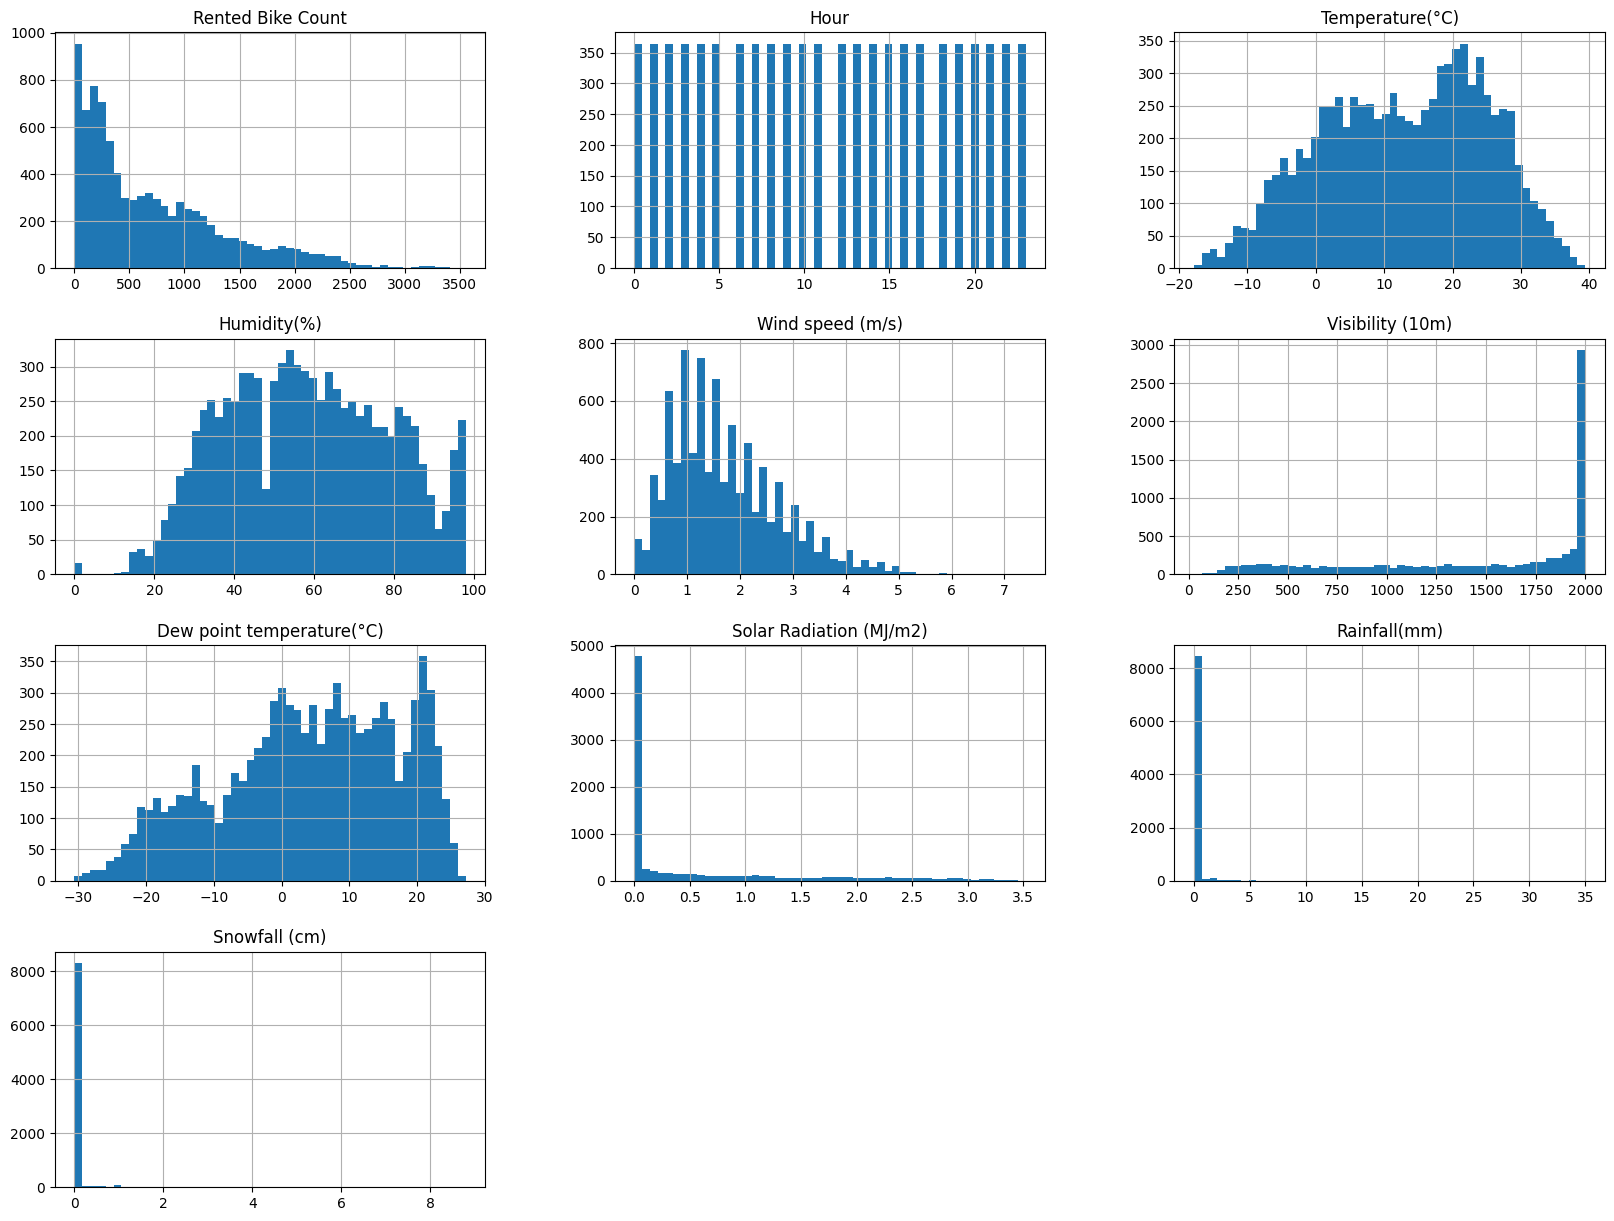

In [17]:
# data visualization fast
dataframe.hist(bins=50, figsize=(20,15))
plt.show()

## Data preparation

In [ ]:
# watch for missing values
dataframe.isna().sum()
# there are no missing values, no need to remove rows

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


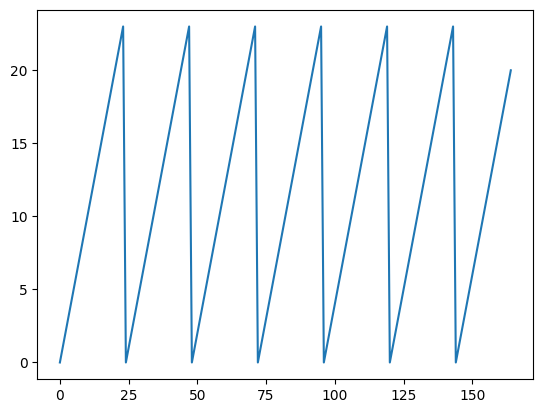

In [21]:
# encode cyclical data
plt.plot(dataframe['Hour'][:165].values)

plt.show()

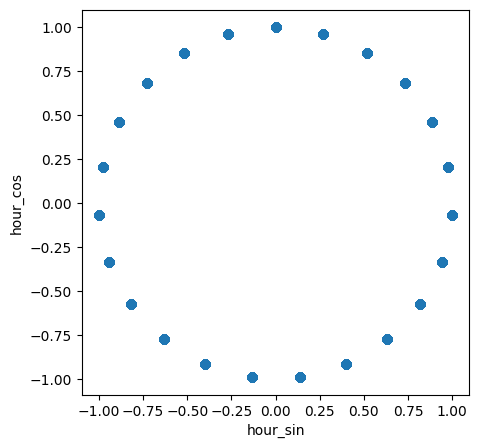

In [23]:
hour_sin = np.sin(2 * np.pi * dataframe['Hour']/23.0)
hour_cos = np.cos(2 * np.pi * dataframe['Hour']/23.0)

plt.figure(figsize=(5, 5))
plt.xlabel('hour_sin')
plt.ylabel('hour_cos')
plt.scatter(hour_sin,hour_cos)

plt.show()

In [24]:
dataframe['hour_sin']=hour_sin
dataframe['hour_cos']=hour_cos

dataframe.sample(row_count)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,hour_sin,hour_cos
1286,23/01/2018,169,14,-10.4,30,4.3,2000,-24.6,1.22,0.0,1.0,Winter,No Holiday,Yes,-0.631088,-0.775711
1292,23/01/2018,178,20,-12.5,52,3.0,2000,-20.3,0.00,0.0,0.9,Winter,No Holiday,Yes,-0.730836,0.682553
7941,27/10/2018,775,21,7.3,49,3.4,2000,-2.7,0.00,0.0,0.0,Autumn,No Holiday,Yes,-0.519584,0.854419
4984,26/06/2018,56,16,23.3,96,3.4,441,22.6,0.08,1.0,0.0,Summer,No Holiday,Yes,-0.942261,-0.334880
7300,01/10/2018,143,4,13.7,56,1.9,2000,5.0,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.887885,0.460065


In [31]:
print(len(dataframe))

8760


In [30]:
# now we drop not useful cols
dataframe = dataframe.drop(['Hour'], axis=1)
dataframe.sample(row_count)

,Date,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,hour_sin,hour_cos
1514,02/02/2018,102,-5.7,59,0.3,1951,-12.4,0.00,0.0,0.0,Winter,No Holiday,Yes,0.519584,0.854419
4083,20/05/2018,347,13.5,41,1.0,2000,0.4,0.00,0.0,0.0,Spring,No Holiday,Yes,0.730836,0.682553
1288,23/01/2018,181,-10.1,34,4.3,2000,-23.0,0.74,0.0,1.0,Winter,No Holiday,Yes,-0.942261,-0.334880
3352,19/04/2018,1198,19.8,25,4.4,1132,-0.8,2.02,0.0,0.0,Spring,No Holiday,Yes,-0.942261,-0.334880
5213,06/07/2018,311,22.5,66,1.5,2000,15.8,0.00,0.0,0.0,Summer,No Holiday,Yes,0.979084,0.203456


In [ ]:
label_enc_dataframe = dataframe.copy()

label_enc_dataframe['']